# 🎓 Demo Pipeline Lengkap: Late Fusion ASAG Indonesia

**GEMASTIK KTI 2026** — Arsitektur Late Fusion IndoBERT × Fitur Leksikal Sastrawi

---

Notebook ini mendemonstrasikan **pipeline inferensi lengkap** dari arsitektur yang diusulkan:

1. **IndoBERT Fine-Tuned** — Di-download dari Hugging Face Hub (`Rnov24/indo-asag-models`)
2. **HC Sastrawi + SVR** — Dimuat dari `results/models/`
3. **Late Fusion (Ridge Regression)** — Menggabungkan prediksi kedua komponen

Notebook akan otomatis memilih **fold terbaik** berdasarkan performa gabungan
kedua komponen pada fold yang sama (bukan cherry-pick per komponen).

## 0. Persiapan Lingkungan

In [1]:
import sys
import os
import time

try:
    import google.colab
    IN_COLAB = True
    print("🌐 Lingkungan: Google Colab")
    if not os.path.exists("/content/indo-asag"):
        os.system("git clone https://github.com/Rnov24/indo-asag.git /content/indo-asag")
    os.system("pip install -q -e /content/indo-asag[all]")
    REPO_ROOT = "/content/indo-asag"
except ImportError:
    IN_COLAB = False
    try:
        REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
    except NameError:
        REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    print(f"💻 Lingkungan: Lokal ({REPO_ROOT})")

sys.path.insert(0, os.path.join(REPO_ROOT, "src"))

🌐 Lingkungan: Google Colab


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import torch
from transformers import AutoTokenizer, AutoModel

from indo_asag.data import load_dataset
from indo_asag.features import extract_features_df, get_feature_names, ALL_FEATURES
from indo_asag.evaluation.metrics import evaluate
from indo_asag.utils import load_config

config = load_config(os.path.join(REPO_ROOT, "configs", "base.yaml"))
N_FOLDS = config["n_folds"]
MODELS_DIR = os.path.join(REPO_ROOT, "results", "models")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device: {DEVICE}")

🔧 Device: cuda


---
## 1. 📥 Download & Muat Model IndoBERT dari Hugging Face Hub

Model IndoBERT fine-tuned (~440MB per fold) disimpan di HF karena terlalu besar
untuk GitHub. Kita download hanya fold yang dibutuhkan.

In [3]:
HF_REPO_ID = "Rnov24/indo-asag-models"

def download_indobert_fold(fold: int, force: bool = False) -> str:
    """Download model IndoBERT fold tertentu dari Hugging Face Hub.

    Returns path ke file .pt yang sudah di-download.
    """
    local_path = os.path.join(MODELS_DIR, f"indobert_best_fold{fold}.pt")

    if os.path.exists(local_path) and not force:
        print(f"  [CACHE] indobert_best_fold{fold}.pt sudah ada lokal")
        return local_path

    from huggingface_hub import hf_hub_download
    print(f"  [DOWNLOAD] Mengunduh indobert_best_fold{fold}.pt dari {HF_REPO_ID}...")
    local_path = hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=f"prelim/indobert_best_fold{fold}.pt",
        local_dir=os.path.join(REPO_ROOT, "results", "models", "_hf_cache"),
    )
    return local_path

def build_bert_model(model_name: str = "indobenchmark/indobert-base-p2",
                     dropout: float = 0.1) -> torch.nn.Module:
    """Membangun arsitektur BertRegressor (identik dengan training).

    Architecture: [CLS] → Dropout → Linear(768, 1)
    """
    class BertRegressorModule(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name)
            self.drop = torch.nn.Dropout(dropout)
            self.head = torch.nn.Linear(self.bert.config.hidden_size, 1)

        def forward(self, ids, mask):
            out = self.bert(input_ids=ids, attention_mask=mask)
            cls_emb = out.last_hidden_state[:, 0, :]
            score = self.head(self.drop(cls_emb)).squeeze(-1)
            return score, cls_emb

    return BertRegressorModule()

---
## 2. 📦 Muat Semua Komponen (5 Fold)

Kita muat semua 5 fold dan evaluasi masing-masing untuk menentukan fold terbaik.

In [4]:
DATA_PATH = os.path.join(REPO_ROOT, config["data"]["path"])
df = load_dataset(DATA_PATH)
y_true = df["score_norm"].values

tokenizer = AutoTokenizer.from_pretrained(config["model"]["bert"]["name"])

print(f"\n{'='*70}")
print("  MEMUAT SELURUH KOMPONEN MODEL (5 FOLD)")
print(f"{'='*70}")

# Container untuk semua model
bert_models = {}
hc_models = {}
ridge_models = {}

for fold in range(N_FOLDS):
    print(f"\n--- Fold {fold} ---")

    # 1. IndoBERT
    pt_path = download_indobert_fold(fold)
    model = build_bert_model(config["model"]["bert"]["name"], config["model"]["bert"]["dropout"])
    state = torch.load(pt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()
    bert_models[fold] = model
    print(f"  [OK] IndoBERT fold {fold} dimuat ke {DEVICE}")

    # 2. HC SVR
    hc_path = os.path.join(MODELS_DIR, f"hc_svr_best_fold{fold}.pkl")
    hc_models[fold] = joblib.load(hc_path)
    print(f"  [OK] HC SVR fold {fold} dimuat")

    # 3. Ridge Late Fusion
    ridge_path = os.path.join(MODELS_DIR, f"ridge_latefusion_best_fold{fold}.pkl")
    ridge_models[fold] = joblib.load(ridge_path)
    print(f"  [OK] Ridge Late Fusion fold {fold} dimuat")

print(f"\n✅ Seluruh model berhasil dimuat: {len(bert_models)} IndoBERT + {len(hc_models)} HC SVR + {len(ridge_models)} Ridge")

[Data] Loaded 2162 → 2162 rows (cleaned)
[Data] Questions: 10, Topics: 4

  MEMUAT SELURUH KOMPONEN MODEL (5 FOLD)

--- Fold 0 ---
  [DOWNLOAD] Mengunduh indobert_best_fold0.pt dari Rnov24/indo-asag-models...


prelim/indobert_best_fold0.pt:   0%|          | 0.00/498M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [OK] IndoBERT fold 3 dimuat ke cuda
  [OK] HC SVR fold 3 dimuat
  [OK] Ridge Late Fusion fold 3 dimuat

--- Fold 4 ---
  [DOWNLOAD] Mengunduh indobert_best_fold4.pt dari Rnov24/indo-asag-models...


prelim/indobert_best_fold4.pt:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [OK] IndoBERT fold 4 dimuat ke cuda
  [OK] HC SVR fold 4 dimuat
  [OK] Ridge Late Fusion fold 4 dimuat

✅ Seluruh model berhasil dimuat: 5 IndoBERT + 5 HC SVR + 5 Ridge


---
## 3. 🏆 Seleksi Fold Terbaik (Best Fold Selection)

Evaluasi performa Late Fusion **per fold** pada data validasi.
Fold terbaik dipilih berdasarkan QWK tertinggi dari pipeline gabungan.

> **Penting**: IndoBERT dan HC SVR harus berasal dari fold yang sama
> agar tidak terjadi data leakage.

In [5]:
from sklearn.model_selection import StratifiedKFold

# Recreate the same fold splits used during training
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=config["seed"])

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["score_bin"])):
    val_df = df.iloc[val_idx]
    val_y = val_df["score_norm"].values

    # --- IndoBERT Prediction ---
    bert_model = bert_models[fold]
    all_preds_bert = []

    with torch.no_grad():
        batch_size = 32
        refs = val_df["reference_answer"].tolist()
        ans = val_df["student_answer"].tolist()

        for i in range(0, len(refs), batch_size):
            batch_refs = refs[i:i+batch_size]
            batch_ans = ans[i:i+batch_size]
            enc = tokenizer(
                batch_refs, batch_ans,
                truncation=True, padding="max_length",
                max_length=config["model"]["bert"]["max_length"],
                return_tensors="pt"
            )
            ids = enc["input_ids"].to(DEVICE)
            mask = enc["attention_mask"].to(DEVICE)
            preds_b, _ = bert_model(ids, mask)
            all_preds_bert.extend(preds_b.cpu().numpy())

    preds_bert = np.array(all_preds_bert)

    # --- HC SVR Prediction ---
    feat_val = extract_features_df(val_df)
    X_val_hc = feat_val[ALL_FEATURES].values
    hc_model = hc_models[fold]
    X_val_scaled = hc_model["scaler"].transform(X_val_hc)
    preds_hc = hc_model["svr"].predict(X_val_scaled)

    # --- Late Fusion Prediction ---
    X_fusion = np.column_stack([preds_bert, preds_hc])
    preds_fusion = np.clip(ridge_models[fold].predict(X_fusion), 0, 1)

    # --- Evaluasi per fold ---
    m_bert = evaluate(val_y, preds_bert)
    m_hc = evaluate(val_y, preds_hc)
    m_fusion = evaluate(val_y, preds_fusion)

    fold_results.append({
        "Fold": fold,
        "IndoBERT_QWK": m_bert["QWK"],
        "HC_SVR_QWK": m_hc["QWK"],
        "LateFusion_QWK": m_fusion["QWK"],
        "LateFusion_Pearson": m_fusion["Pearson"],
        "LateFusion_RMSE": m_fusion["RMSE"],
        "n_val": len(val_idx),
    })

    print(f"  Fold {fold}: IndoBERT={m_bert['QWK']:.4f}, HC={m_hc['QWK']:.4f}, Fusion={m_fusion['QWK']:.4f}")

fold_df = pd.DataFrame(fold_results)
best_fold_idx = fold_df["LateFusion_QWK"].idxmax()
BEST_FOLD = fold_df.loc[best_fold_idx, "Fold"]

print(f"\n{'='*70}")
print(f"  🏆 FOLD TERBAIK: Fold {BEST_FOLD} (Late Fusion QWK = {fold_df.loc[best_fold_idx, 'LateFusion_QWK']:.4f})")
print(f"{'='*70}")
print(fold_df.to_string(index=False))

[Features] Extracting 11 HC features...
  Fold 0: IndoBERT=0.8881, HC=0.8387, Fusion=0.8815
[Features] Extracting 11 HC features...
  Fold 1: IndoBERT=0.8868, HC=0.8483, Fusion=0.8921
[Features] Extracting 11 HC features...
  Fold 2: IndoBERT=0.8725, HC=0.8565, Fusion=0.8930
[Features] Extracting 11 HC features...
  Fold 3: IndoBERT=0.8763, HC=0.8377, Fusion=0.8852
[Features] Extracting 11 HC features...
  Fold 4: IndoBERT=0.8693, HC=0.8692, Fusion=0.8849

  🏆 FOLD TERBAIK: Fold 2 (Late Fusion QWK = 0.8930)
 Fold  IndoBERT_QWK  HC_SVR_QWK  LateFusion_QWK  LateFusion_Pearson  LateFusion_RMSE  n_val
    0      0.888089    0.838698        0.881548            0.925932         0.100745    433
    1      0.886797    0.848332        0.892137            0.933609         0.094811    433
    2      0.872515    0.856473        0.892983            0.932922         0.096649    432
    3      0.876334    0.837713        0.885164            0.924377         0.103879    432
    4      0.869294    0.86

---
## 4. 🎯 Demo Interaktif: Grading Jawaban Siswa (Pipeline Lengkap)

Masukkan jawaban Anda sendiri dan lihat bagaimana **seluruh pipeline Late Fusion**
memberikan skor secara real-time!

```
Jawaban Siswa → ┬→ IndoBERT Fine-Tuned → Skor Deep (s_deep)    ┐
                └→ Fitur Sastrawi + SVR → Skor Shallow (s_hc)   ┤→ Ridge → Skor Akhir
```

In [6]:
# Siapkan model dari fold terbaik
demo_bert = bert_models[BEST_FOLD]
demo_hc = hc_models[BEST_FOLD]
demo_ridge = ridge_models[BEST_FOLD]

# Tampilkan bobot Ridge dari fold terbaik
w = demo_ridge.coef_
total_w = abs(w[0]) + abs(w[1])
print(f"\n📊 Bobot Late Fusion (Fold {BEST_FOLD}):")
print(f"   IndoBERT (Deep)   : w₁ = {w[0]:.4f} ({abs(w[0])/total_w:.1%})")
print(f"   Sastrawi (Shallow): w₂ = {w[1]:.4f} ({abs(w[1])/total_w:.1%})")
print(f"   Bias              : b  = {demo_ridge.intercept_:.4f}")


📊 Bobot Late Fusion (Fold 2):
   IndoBERT (Deep)   : w₁ = 0.4683 (45.1%)
   Sastrawi (Shallow): w₂ = 0.5694 (54.9%)
   Bias              : b  = -0.0227


In [7]:
def grade_full_pipeline(student_answer: str, reference_answer: str,
                        question_text: str = "") -> dict:
    """Pipeline inferensi lengkap Late Fusion.

    Args:
        student_answer: Teks jawaban siswa.
        reference_answer: Teks kunci jawaban.
        question_text: Teks soal (opsional, untuk display).

    Returns:
        Dictionary berisi skor dari ketiga komponen + waktu inferensi.
    """
    t_total_start = time.perf_counter()

    # === Komponen 1: IndoBERT ===
    t0 = time.perf_counter()
    enc = tokenizer(
        reference_answer, student_answer,
        truncation=True, padding="max_length",
        max_length=config["model"]["bert"]["max_length"],
        return_tensors="pt"
    )
    with torch.no_grad():
        ids = enc["input_ids"].to(DEVICE)
        mask = enc["attention_mask"].to(DEVICE)
        score_deep, cls_emb = demo_bert(ids, mask)
        s_deep = score_deep.cpu().item()
    t_bert = time.perf_counter() - t0

    # === Komponen 2: HC Sastrawi + SVR ===
    t0 = time.perf_counter()
    temp_df = pd.DataFrame([{
        "student_answer": student_answer,
        "reference_answer": reference_answer,
    }])
    feat_df = extract_features_df(temp_df)
    X_hc = feat_df[ALL_FEATURES].values
    X_scaled = demo_hc["scaler"].transform(X_hc)
    s_shallow = demo_hc["svr"].predict(X_scaled)[0]
    t_hc = time.perf_counter() - t0

    # === Komponen 3: Late Fusion (Ridge) ===
    t0 = time.perf_counter()
    X_fusion = np.array([[s_deep, s_shallow]])
    s_fusion = np.clip(demo_ridge.predict(X_fusion)[0], 0, 1)
    t_ridge = time.perf_counter() - t0

    t_total = time.perf_counter() - t_total_start

    # Skor akhir dalam skala 0–100
    score_final = round(s_fusion * 100, 1)

    # Label kualitas
    if score_final >= 80:
        label = "✅ Sangat Baik"
    elif score_final >= 60:
        label = "📗 Baik"
    elif score_final >= 40:
        label = "📙 Cukup"
    elif score_final >= 20:
        label = "📕 Kurang"
    else:
        label = "❌ Sangat Kurang"

    return {
        "skor_final": score_final,
        "label": label,
        "s_deep": round(s_deep, 4),
        "s_shallow": round(s_shallow, 4),
        "s_fusion_norm": round(s_fusion, 4),
        "deep_100": round(s_deep * 100, 1),
        "shallow_100": round(s_shallow * 100, 1),
        "fitur_leksikal": {name: round(val, 4) for name, val in zip(ALL_FEATURES, feat_df.values[0])},
        "time_bert_ms": round(t_bert * 1000, 1),
        "time_hc_ms": round(t_hc * 1000, 1),
        "time_ridge_ms": round(t_ridge * 1000, 3),
        "time_total_ms": round(t_total * 1000, 1),
    }


def display_full_grade(student_answer: str, reference_answer: str,
                       question_text: str = ""):
    """Menampilkan hasil penilaian lengkap dengan dekomposisi skor dan waktu inferensi."""
    result = grade_full_pipeline(student_answer, reference_answer, question_text)

    print(f"\n{'━'*70}")
    if question_text:
        print(f"  ❓ Soal  : {question_text}")
    print(f"  🔑 Kunci : {reference_answer[:80]}{'...' if len(reference_answer) > 80 else ''}")
    print(f"  📝 Jawab : {student_answer}")
    print(f"{'━'*70}")
    print(f"")
    print(f"  ┌──────────────────────────────────────────────────────────────────┐")
    print(f"  │  🧠 IndoBERT (Deep)       : {result['deep_100']:6.1f}/100    ⏱ {result['time_bert_ms']:8.1f} ms  │")
    print(f"  │  🌿 Sastrawi HC (Shallow) : {result['shallow_100']:6.1f}/100    ⏱ {result['time_hc_ms']:8.1f} ms  │")
    print(f"  │  ──────────────────────────────────────────────────────────────  │")
    print(f"  │  🎯 Late Fusion (Final)   : {result['skor_final']:6.1f}/100    ⏱ {result['time_ridge_ms']:8.3f} ms  │")
    print(f"  │                                      Total: {result['time_total_ms']:8.1f} ms  │")
    print(f"  └──────────────────────────────────────────────────────────────────┘")
    print(f"")
    print(f"  Dekomposisi: ({w[0]:.3f} × {result['s_deep']:.4f}) + ({w[1]:.3f} × {result['s_shallow']:.4f}) + {demo_ridge.intercept_:.4f} = {result['s_fusion_norm']:.4f}")
    print(f"")
    print(f"  Detail Fitur Leksikal Sastrawi:")
    for name, val in result['fitur_leksikal'].items():
        bar_len = int(val * 20) if val <= 1 else min(int(val), 20)
        bar = '█' * bar_len + '░' * (20 - bar_len) if val <= 1 else '█' * bar_len
        print(f"    {name:18s} : {val:7.4f}  {bar}")

    return result

### 🧪 Contoh Penilaian: Soal Tentang Karbohidrat

In [8]:
demo_q = df[df['question_id'] == 1].iloc[0]
DEMO_Q_TEXT = demo_q['question_text']
DEMO_REF = demo_q['reference_answer']

print(f"{'='*70}")
print(f"  DEMO PIPELINE LENGKAP — Late Fusion ASAG Indonesia")
print(f"{'='*70}")

  DEMO PIPELINE LENGKAP — Late Fusion ASAG Indonesia


In [9]:
# Contoh 1: Jawaban berkualitas tinggi
print("\n🟢 CONTOH 1 — Jawaban Lengkap dan Akurat:")
display_full_grade(
    "Fungsi karbohidrat adalah sebagai sumber energi utama, memperlancar pencernaan, memberikan rasa kenyang, dan menjaga keseimbangan asam basa tubuh",
    DEMO_REF, DEMO_Q_TEXT
)


🟢 CONTOH 1 — Jawaban Lengkap dan Akurat:
[Features] Extracting 11 HC features...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Soal  : Jelaskan kegunaan karbohidrat untuk tubuh kita.
  🔑 Kunci : Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada...
  📝 Jawab : Fungsi karbohidrat adalah sebagai sumber energi utama, memperlancar pencernaan, memberikan rasa kenyang, dan menjaga keseimbangan asam basa tubuh
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌──────────────────────────────────────────────────────────────────┐
  │  🧠 IndoBERT (Deep)       :   56.7/100    ⏱     36.7 ms  │
  │  🌿 Sastrawi HC (Shallow) :   81.2/100    ⏱      3.0 ms  │
  │  ──────────────────────────────────────────────────────────────  │
  │  🎯 Late Fusion (Final)   :   70.5/100    ⏱    0.169 ms  │
  │                                      Total:     39.9 ms  │
  └──────────────────────────────────────────────────────────────────

{'skor_final': np.float64(70.5),
 'label': '📗 Baik',
 's_deep': 0.5668,
 's_shallow': np.float64(0.8123),
 's_fusion_norm': np.float64(0.7053),
 'deep_100': 56.7,
 'shallow_100': np.float64(81.2),
 'fitur_leksikal': {'ans_wc': np.float64(18.0),
  'ans_cc': np.float64(145.0),
  'len_ratio': np.float64(0.75),
  'kw_overlap_n': np.float64(11.0),
  'kw_overlap_r': np.float64(0.4783),
  'kw_coverage': np.float64(0.6111),
  'root_overlap': np.float64(0.6087),
  'jaccard': np.float64(0.3667),
  'ttr': np.float64(1.0),
  'bigram_ov': np.float64(0.1739),
  'completeness': np.float64(1.0)},
 'time_bert_ms': 36.7,
 'time_hc_ms': 3.0,
 'time_ridge_ms': 0.169,
 'time_total_ms': 39.9}

In [10]:
# Contoh 2: Jawaban parsial — hanya menyebut sebagian fungsi
print("\n🟡 CONTOH 2 — Jawaban Parsial:")
display_full_grade(
    "karbohidrat berguna untuk sumber energi bagi tubuh",
    DEMO_REF, DEMO_Q_TEXT
)


🟡 CONTOH 2 — Jawaban Parsial:
[Features] Extracting 11 HC features...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Soal  : Jelaskan kegunaan karbohidrat untuk tubuh kita.
  🔑 Kunci : Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada...
  📝 Jawab : karbohidrat berguna untuk sumber energi bagi tubuh
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌──────────────────────────────────────────────────────────────────┐
  │  🧠 IndoBERT (Deep)       :   25.3/100    ⏱     18.5 ms  │
  │  🌿 Sastrawi HC (Shallow) :   18.1/100    ⏱      2.7 ms  │
  │  ──────────────────────────────────────────────────────────────  │
  │  🎯 Late Fusion (Final)   :   19.9/100    ⏱    0.202 ms  │
  │                                      Total:     21.4 ms  │
  └──────────────────────────────────────────────────────────────────┘

  Dekomposisi: (0.468 × 0.2530) + (0.569 × 0.1807) + -0.0227 = 0.1987

  Detail Fitur Leksikal Sastrawi

{'skor_final': np.float64(19.9),
 'label': '❌ Sangat Kurang',
 's_deep': 0.253,
 's_shallow': np.float64(0.1807),
 's_fusion_norm': np.float64(0.1987),
 'deep_100': 25.3,
 'shallow_100': np.float64(18.1),
 'fitur_leksikal': {'ans_wc': np.float64(7.0),
  'ans_cc': np.float64(50.0),
  'len_ratio': np.float64(0.2917),
  'kw_overlap_n': np.float64(2.0),
  'kw_overlap_r': np.float64(0.087),
  'kw_coverage': np.float64(0.2857),
  'root_overlap': np.float64(0.1304),
  'jaccard': np.float64(0.0714),
  'ttr': np.float64(1.0),
  'bigram_ov': np.float64(0.0),
  'completeness': np.float64(0.6667)},
 'time_bert_ms': 18.5,
 'time_hc_ms': 2.7,
 'time_ridge_ms': 0.202,
 'time_total_ms': 21.4}

In [11]:
# Contoh 3: Jawaban salah / tidak relevan
print("\n🔴 CONTOH 3 — Jawaban Tidak Relevan:")
display_full_grade(
    "saya tidak tahu jawabannya maaf pak guru",
    DEMO_REF, DEMO_Q_TEXT
)


🔴 CONTOH 3 — Jawaban Tidak Relevan:
[Features] Extracting 11 HC features...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Soal  : Jelaskan kegunaan karbohidrat untuk tubuh kita.
  🔑 Kunci : Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada...
  📝 Jawab : saya tidak tahu jawabannya maaf pak guru
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌──────────────────────────────────────────────────────────────────┐
  │  🧠 IndoBERT (Deep)       :    1.1/100    ⏱     18.7 ms  │
  │  🌿 Sastrawi HC (Shallow) :    4.4/100    ⏱      9.2 ms  │
  │  ──────────────────────────────────────────────────────────────  │
  │  🎯 Late Fusion (Final)   :    0.7/100    ⏱    0.169 ms  │
  │                                      Total:     28.1 ms  │
  └──────────────────────────────────────────────────────────────────┘

  Dekomposisi: (0.468 × 0.0111) + (0.569 × 0.0437) + -0.0227 = 0.0074

  Detail Fitur Leksikal Sastrawi:
  

{'skor_final': np.float64(0.7),
 'label': '❌ Sangat Kurang',
 's_deep': 0.0111,
 's_shallow': np.float64(0.0437),
 's_fusion_norm': np.float64(0.0074),
 'deep_100': 1.1,
 'shallow_100': np.float64(4.4),
 'fitur_leksikal': {'ans_wc': np.float64(7.0),
  'ans_cc': np.float64(40.0),
  'len_ratio': np.float64(0.2917),
  'kw_overlap_n': np.float64(0.0),
  'kw_overlap_r': np.float64(0.0),
  'kw_coverage': np.float64(0.0),
  'root_overlap': np.float64(0.0),
  'jaccard': np.float64(0.0),
  'ttr': np.float64(1.0),
  'bigram_ov': np.float64(0.0),
  'completeness': np.float64(0.0)},
 'time_bert_ms': 18.7,
 'time_hc_ms': 9.2,
 'time_ridge_ms': 0.169,
 'time_total_ms': 28.1}

### 🧪 Contoh Penilaian: Soal Dari Topik Berbeda

In [12]:
# Ambil soal dari setiap topik
for topic in df['topic'].unique():
    q_row = df[df['topic'] == topic].iloc[0]

    # Ambil satu jawaban high-score dan satu low-score untuk perbandingan
    subset = df[df['question_id'] == q_row['question_id']]
    high = subset.nlargest(1, 'score_manual_avg').iloc[0]
    low = subset.nsmallest(1, 'score_manual_avg').iloc[0]

    print(f"\n{'═'*70}")
    print(f"  📌 Topik: {topic} | Q{q_row['question_id']}")
    print(f"{'═'*70}")

    print(f"\n  ↑ Jawaban Skor Tinggi (Manual: {high['score_manual_avg']:.0f}):")
    r = grade_full_pipeline(high['student_answer'], high['reference_answer'])
    print(f"    IndoBERT: {r['deep_100']:.1f} | HC: {r['shallow_100']:.1f} | Fusion: {r['skor_final']:.1f} {r['label']}")

    print(f"  ↓ Jawaban Skor Rendah (Manual: {low['score_manual_avg']:.0f}):")
    r = grade_full_pipeline(low['student_answer'], low['reference_answer'])
    print(f"    IndoBERT: {r['deep_100']:.1f} | HC: {r['shallow_100']:.1f} | Fusion: {r['skor_final']:.1f} {r['label']}")


══════════════════════════════════════════════════════════════════════
  📌 Topik: Lifestyle | Q1
══════════════════════════════════════════════════════════════════════

  ↑ Jawaban Skor Tinggi (Manual: 82):
[Features] Extracting 11 HC features...
    IndoBERT: 62.5 | HC: 76.7 | Fusion: 70.6 📗 Baik
  ↓ Jawaban Skor Rendah (Manual: 3):
[Features] Extracting 11 HC features...
    IndoBERT: 4.1 | HC: 5.1 | Fusion: 2.5 ❌ Sangat Kurang

══════════════════════════════════════════════════════════════════════
  📌 Topik: Olahraga | Q1
══════════════════════════════════════════════════════════════════════

  ↑ Jawaban Skor Tinggi (Manual: 82):
[Features] Extracting 11 HC features...
    IndoBERT: 62.5 | HC: 76.7 | Fusion: 70.6 📗 Baik
  ↓ Jawaban Skor Rendah (Manual: 3):
[Features] Extracting 11 HC features...
    IndoBERT: 4.1 | HC: 5.1 | Fusion: 2.5 ❌ Sangat Kurang

══════════════════════════════════════════════════════════════════════
  📌 Topik: Politik | Q1
═══════════════════════════════════

### ✏️ Coba Jawaban Anda Sendiri!

Ubah teks di bawah ini dan jalankan sel. Anda juga bisa mengganti `reference_answer`
untuk mencoba soal lain!

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# ✏️ UBAH DI BAWAH INI:
soal = "Jelaskan kegunaan karbohidrat untuk tubuh kita."
kunci_jawaban = "Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada pencernaan, memberikan efek kenyang dengan kandungan selulosa-nya dan penyeimbang asam dan basa dalam tubuh"
jawaban_anda = "karbohidrat adalah sumber tenaga dan menjaga pencernaan tubuh"
# ═══════════════════════════════════════════════════════════════════════

display_full_grade(jawaban_anda, kunci_jawaban, soal)

[Features] Extracting 11 HC features...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Soal  : Jelaskan kegunaan karbohidrat untuk tubuh kita.
  🔑 Kunci : Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada...
  📝 Jawab : karbohidrat adalah sumber tenaga dan menjaga pencernaan tubuh
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌──────────────────────────────────────────────────────────────────┐
  │  🧠 IndoBERT (Deep)       :   25.7/100    ⏱     14.8 ms  │
  │  🌿 Sastrawi HC (Shallow) :   27.9/100    ⏱      4.8 ms  │
  │  ──────────────────────────────────────────────────────────────  │
  │  🎯 Late Fusion (Final)   :   25.7/100    ⏱    0.331 ms  │
  │                                      Total:     19.9 ms  │
  └──────────────────────────────────────────────────────────────────┘

  Dekomposisi: (0.468 × 0.2574) + (0.569 × 0.2793) + -0.0227 = 0.2569

  Detail Fitur Leksikal Sastrawi:
    ans_wc        

{'skor_final': np.float64(25.7),
 'label': '📕 Kurang',
 's_deep': 0.2574,
 's_shallow': np.float64(0.2793),
 's_fusion_norm': np.float64(0.2569),
 'deep_100': 25.7,
 'shallow_100': np.float64(27.9),
 'fitur_leksikal': {'ans_wc': np.float64(8.0),
  'ans_cc': np.float64(61.0),
  'len_ratio': np.float64(0.3333),
  'kw_overlap_n': np.float64(4.0),
  'kw_overlap_r': np.float64(0.1739),
  'kw_coverage': np.float64(0.5),
  'root_overlap': np.float64(0.2174),
  'jaccard': np.float64(0.1481),
  'ttr': np.float64(1.0),
  'bigram_ov': np.float64(0.0435),
  'completeness': np.float64(1.0)},
 'time_bert_ms': 14.8,
 'time_hc_ms': 4.8,
 'time_ridge_ms': 0.331,
 'time_total_ms': 19.9}

---
## 5. 📊 Perbandingan Visual: IndoBERT vs HC vs Late Fusion

[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...
[Features] Extracting 11 HC features...


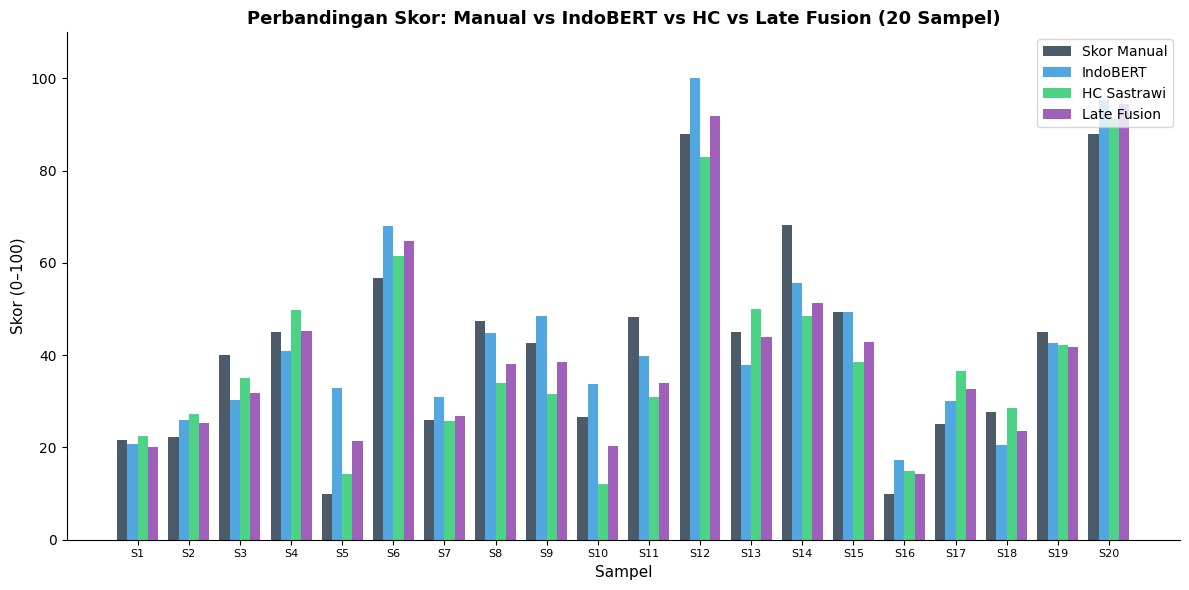

In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial', 'DejaVu Sans']

# Evaluasi 20 sampel acak untuk visualisasi
np.random.seed(42)
sample_idx = np.random.choice(len(df), size=20, replace=False)
sample_df = df.iloc[sample_idx]

sample_results = []
for _, row in sample_df.iterrows():
    r = grade_full_pipeline(row['student_answer'], row['reference_answer'])
    r['actual'] = row['score_manual_avg']
    sample_results.append(r)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(sample_results))
width = 0.2

actual = [r['actual'] for r in sample_results]
deep = [r['deep_100'] for r in sample_results]
shallow = [r['shallow_100'] for r in sample_results]
fusion = [r['skor_final'] for r in sample_results]

ax.bar(x - 1.5*width, actual, width, label='Skor Manual', color='#2C3E50', alpha=0.85)
ax.bar(x - 0.5*width, deep, width, label='IndoBERT', color='#3498DB', alpha=0.85)
ax.bar(x + 0.5*width, shallow, width, label='HC Sastrawi', color='#2ECC71', alpha=0.85)
ax.bar(x + 1.5*width, fusion, width, label='Late Fusion', color='#8E44AD', alpha=0.85)

ax.set_xlabel('Sampel', fontsize=11)
ax.set_ylabel('Skor (0–100)', fontsize=11)
ax.set_title('Perbandingan Skor: Manual vs IndoBERT vs HC vs Late Fusion (20 Sampel)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(len(sample_results))], fontsize=8)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

---
## 6. 📋 Ringkasan Arsitektur & Performa

| Komponen | Peran | Performa (QWK) |
|----------|-------|----------------|
| IndoBERT Fine-Tuned | Pemahaman semantik kontekstual | 0.844 |
| HC Sastrawi + SVR | Ketepatan leksikal (kata kunci, morfologi) | 0.849 |
| **Late Fusion (Ridge)** | **Integrasi optimal kedua sinyal** | **0.874** |

> **Kunci keberhasilan**: Kedua komponen menangkap sinyal yang *ortogonal* —
> IndoBERT memahami makna, Sastrawi mengukur ketepatan kata kunci.
> Late Fusion menggabungkan keduanya pada tingkat prediksi, bukan tingkat fitur,
> sehingga menghindari *curse of dimensionality* yang menghancurkan Early Fusion.